# CIFAR-100 — Simple ResNet

A lightweight ResNet with one `SimpleResBlock` per stage (4 stages).
This introduces residual connections to the baseline CNN to demonstrate
their impact on gradient flow and convergence.

## Imports

In [11]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

from utils.dataset import get_cifar100_dataloaders, CIFAR100_CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch

## Device Setup

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data Pipeline

In [13]:
batch_size = 64

trainloader, valloader, testloader = get_cifar100_dataloaders(
    batch_size=batch_size, num_workers=4, img_size=32,
)

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')

Train batches: 625 | Val batches: 157 | Test batches: 157


## Visualize Sample Batch

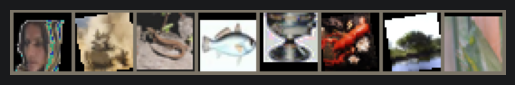

woman tank  lizard trout cup   lobster willow_tree caterpillar


In [14]:
show_sample_batch(trainloader, CIFAR100_CLASSES)

## Model Definition

### SimpleResBlock
A basic residual block: two 3×3 convolutions with BatchNorm and a
1×1 shortcut projection when dimensions change.

### SimpleResNet
Initial conv → 4 residual stages → Global Average Pooling → FC.

In [15]:
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(c, c // r, bias=False),
            nn.ReLU(),
            nn.Linear(c // r, c, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.se(x).view(x.size(0), -1, 1, 1)

class SimpleResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(SimpleResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        # self.se = SEBlock(out_channels)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # out = self.se(out)
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class SimpleResNet(nn.Module):
    def __init__(self):
        super(SimpleResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = SimpleResBlock(64, 64, stride=1)
        self.layer2 = SimpleResBlock(64, 128, stride=2)
        self.layer3 = SimpleResBlock(128, 256, stride=2)
        self.layer4 = SimpleResBlock(256, 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, 100)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

## Initialize Model & Print Summary

In [16]:
model = SimpleResNet().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

SimpleResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): SimpleResBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential()
  )
  (layer2): SimpleResBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running

## Training Configuration

In [17]:
criterion = nn.CrossEntropyLoss()
epochs = 120
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=4e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.20,
    anneal_strategy='cos',
    div_factor=15,
    final_div_factor=1e4,
)

scaler = torch.amp.GradScaler('cuda')
NAME = 'simple_resnet_v4.1_100'
checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path=f'../checkpoint/{NAME}_latest.pth',
    best_model_path=f'../checkpoint/{NAME}_best.pth',
    mode='max',
    verbose=True,
)

## Training Loop

In [18]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint, log=True,
)

[RunLogger] Logging to 'logs/3767300616/'  —  run: 'simpleresnet_20260522_094910'
[ModelCheckpoint] New best (max): 14.2500 — saved to ..\checkpoint\simple_resnet_v4.1_100_best.pth
Epoch [ 1/120]  Train Loss: 4.0523  Val Loss: 3.6205  Val Acc: 14.25%  LR: 0.007066  Time: 12.21s
[ModelCheckpoint] New best (max): 22.7700 — saved to ..\checkpoint\simple_resnet_v4.1_100_best.pth
Epoch [ 2/120]  Train Loss: 3.5226  Val Loss: 3.1339  Val Acc: 22.77%  LR: 0.008257  Time: 4.77s
[ModelCheckpoint] New best (max): 28.9400 — saved to ..\checkpoint\simple_resnet_v4.1_100_best.pth
Epoch [ 3/120]  Train Loss: 3.1763  Val Loss: 2.8462  Val Acc: 28.94%  LR: 0.010219  Time: 4.66s
[ModelCheckpoint] New best (max): 29.4900 — saved to ..\checkpoint\simple_resnet_v4.1_100_best.pth
Epoch [ 4/120]  Train Loss: 2.9193  Val Loss: 2.8150  Val Acc: 29.49%  LR: 0.012920  Time: 4.71s
[ModelCheckpoint] New best (max): 37.9700 — saved to ..\checkpoint\simple_resnet_v4.1_100_best.pth
Epoch [ 5/120]  Train Loss: 2.7190

## Restore Best Weights & Test Evaluation

In [19]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:5s}: {acc:.1f}%')

[ModelCheckpoint] Restored best weights from ..\checkpoint\simple_resnet_v4.1_100_best.pth (score=75.7800)

Overall Test Accuracy: 74.59%

  apple: 88.0%
  aquarium_fish: 88.0%
  baby : 66.0%
  bear : 54.0%
  beaver: 57.0%
  bed  : 79.0%
  bee  : 74.0%
  beetle: 76.0%
  bicycle: 89.0%
  bottle: 81.0%
  bowl : 55.0%
  boy  : 47.0%
  bridge: 83.0%
  bus  : 72.0%
  butterfly: 70.0%
  camel: 80.0%
  can  : 72.0%
  castle: 87.0%
  caterpillar: 70.0%
  cattle: 71.0%
  chair: 90.0%
  chimpanzee: 91.0%
  clock: 67.0%
  cloud: 82.0%
  cockroach: 84.0%
  couch: 58.0%
  crab : 73.0%
  crocodile: 65.0%
  cup  : 81.0%
  dinosaur: 78.0%
  dolphin: 69.0%
  elephant: 69.0%
  flatfish: 69.0%
  forest: 65.0%
  fox  : 83.0%
  girl : 50.0%
  hamster: 83.0%
  house: 79.0%
  kangaroo: 70.0%
  keyboard: 90.0%
  lamp : 75.0%
  lawn_mower: 92.0%
  leopard: 71.0%
  lion : 82.0%
  lizard: 57.0%
  lobster: 69.0%
  man  : 56.0%
  maple_tree: 68.0%
  motorcycle: 93.0%
  mountain: 82.0%
  mouse: 61.0%
  mushroom: 79

## Training Curves

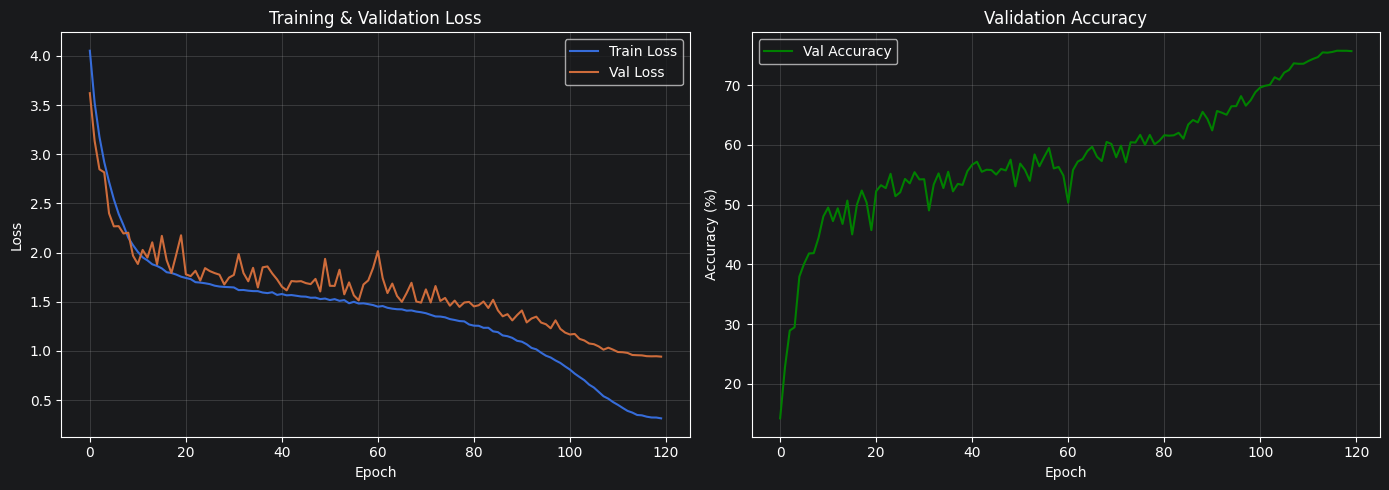

In [20]:
plot_training_curves(train_losses, val_losses, val_accuracies)